In [79]:
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [80]:
def collect_tb_results(run_dir):
    run_dir = Path(run_dir)

    tb_dirs = sorted(set(p.parent for p in run_dir.rglob("events.out.tfevents*")))
    rows = []

    def parse_shift(path_str):
        m = re.search(r"tardatatype-medium-([0-9.]+)", path_str)
        if m:
            return float(m.group(1))
        m = re.search(r"shift([0-9.]+)", path_str)
        if m:
            return float(m.group(1))
        return np.nan

    for tb_dir in tb_dirs:
        event_files = sorted(
            tb_dir.glob("events.out.tfevents*"),
            key=lambda p: p.stat().st_mtime
        )
        if len(event_files) == 0:
            continue

        event_path = event_files[-1]

        ea = EventAccumulator(str(event_path))
        ea.Reload()
        tags = ea.Tags()["scalars"]

        def get_last(*candidate_tags):
            for tag in candidate_tags:
                if tag in tags:
                    vals = ea.Scalars(tag)
                    if len(vals) == 0:
                        continue
                    last = vals[-1].value
                    last5 = np.mean([v.value for v in vals[-5:]])
                    return last, last5
            return np.nan, np.nan

        src_last, src_mean = get_last("test/source_return", "test/source return")
        trg_last, trg_mean = get_last("test/target_return", "test/target return")
        norm_last, norm_mean = get_last("test/target_normalized_score", "test/target normalized score")

        p = str(event_path)

        if "DARA" in p:
            policy = "DARA"
        elif "IQL" in p:
            policy = "IQL"
        elif "MOBODY" in p:
            policy = "MOBODY"
        else:
            policy = "UNKNOWN"

        if "walker2d-friction" in p:
            env = "walker2d-friction"
        elif "hopper-friction" in p:
            env = "hopper-friction"
        elif "halfcheetah-friction" in p:
            env = "halfcheetah-friction"
        else:
            env = "UNKNOWN"

        run_name = tb_dir.parent.name if tb_dir.name == "tb" else tb_dir.name

        rows.append({
            "tb_dir": str(tb_dir),
            "event_path": str(event_path),
            "policy": policy,
            "env": env,
            "shift_level": parse_shift(p),
            "run_name": run_name,
            "src_return_last": src_last,
            "src_return_mean": src_mean,
            "trg_return_last": trg_last,
            "trg_return_mean": trg_mean,
            "norm_score_last": norm_last,
            "norm_score_mean": norm_mean,
        })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df.sort_values(["env", "shift_level", "policy", "run_name"], inplace=True)

    return df

In [81]:
df_base = collect_tb_results("runs_friction_shift_sweep_seed1")
df_prop = collect_tb_results("runs_friction_shift_sweep_seed1_proposed_v2")

In [82]:
base_mobody = df_base[df_base["policy"] == "MOBODY"].copy()
prop_mobody = df_prop[df_prop["policy"] == "MOBODY"].copy()

metric_candidates = [
    "src_return_last",
    "src_return_mean",
    "trg_return_last",
    "trg_return_mean",
    "norm_score_last",
    "norm_score_mean",
]

metrics = [m for m in metric_candidates if m in df_base.columns and m in df_prop.columns]

In [83]:
prop_mobody['event_path'].unique()

array(['runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medium-tardatatype-medium-0.1/r1_v2_bc/tb/events.out.tfevents.1779014234.62908da3e222',
       'runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medium-tardatatype-medium-0.1/r1_v2_both/tb/events.out.tfevents.1779028605.62908da3e222',
       'runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medium-tardatatype-medium-0.5/r1_v2_bc/tb/events.out.tfevents.1779015828.62908da3e222',
       'runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medium-tardatatype-medium-0.5/r1_v2_both/tb/events.out.tfevents.1779032746.62908da3e222',
       'runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medium-tardatatype-medium-2.0/r1_v2_bc/tb/events.out.tfevents.1779017433.62908da3e222',
       'runs_friction_shift_sweep_seed1_proposed_v2/MOBODY/halfcheetah-friction-srcdatatype-medi

In [84]:
keys = ["env", "shift_level"]

base_sum = (
    base_mobody
    .groupby(keys)[metrics]
    .mean()
    .reset_index()
)

prop_sum = (
    prop_mobody
    .groupby(keys + ["run_name"])[metrics]
    .mean()
    .reset_index()
)

# =========================
# 4. 기존 MOBODY vs 제안 MOBODY 병합
# =========================
compare = prop_sum.merge(
    base_sum,
    on=keys,
    suffixes=("_prop", "_base")
)

# 차이 및 개선율 계산
for m in metrics:
    compare[f"{m}_diff"] = compare[f"{m}_prop"] - compare[f"{m}_base"]
    compare[f"{m}_improve_%"] = (
        compare[f"{m}_diff"] / compare[f"{m}_base"].replace(0, np.nan) * 100
    )

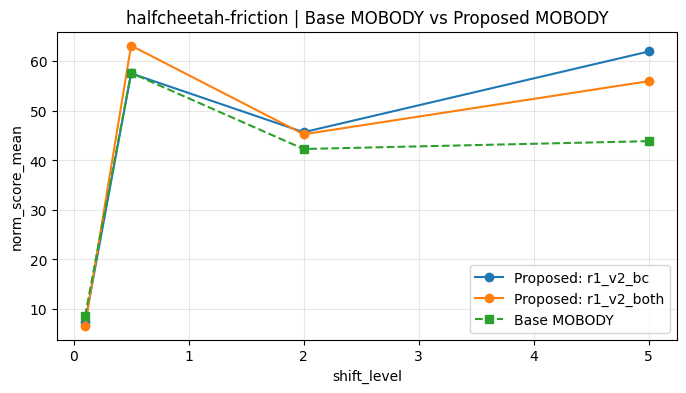

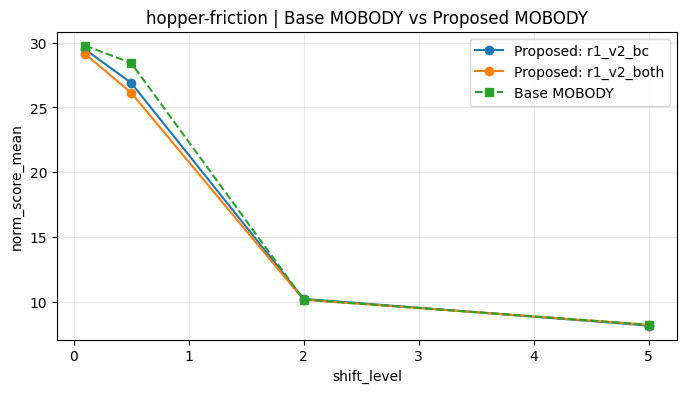

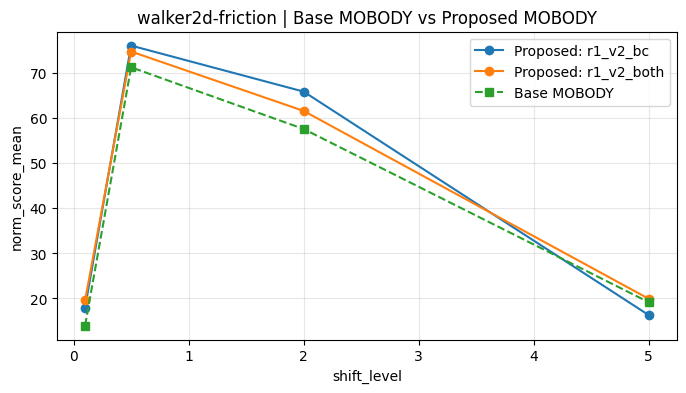

In [85]:
main_metric = "norm_score_mean"  # 원하는 metric으로 변경

for env in compare["env"].unique():
    tmp = compare[compare["env"] == env].copy()
    
    plt.figure(figsize=(8, 4))
    
    for run_name in tmp["run_name"].unique():
        t = tmp[tmp["run_name"] == run_name]
        plt.plot(
            t["shift_level"],
            t[f"{main_metric}_prop"],
            marker="o",
            label=f"Proposed: {run_name}"
        )
    
    # 기존 MOBODY는 run_name과 무관하게 동일하므로 하나만 그림
    base_tmp = (
        tmp[["shift_level", f"{main_metric}_base"]]
        .drop_duplicates()
        .sort_values("shift_level")
    )
    
    plt.plot(
        base_tmp["shift_level"],
        base_tmp[f"{main_metric}_base"],
        marker="s",
        linestyle="--",
        label="Base MOBODY"
    )
    
    plt.title(f"{env} | Base MOBODY vs Proposed MOBODY")
    plt.xlabel("shift_level")
    plt.ylabel(main_metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [86]:
def make_compare_by_run(df_base, df_prop, prop_run_name, main_metric="norm_score_mean"):
    keys = ["env", "shift_level"]
    
    base = (
        df_base[df_base["policy"] == "MOBODY"]
        .groupby(keys)
        .mean(numeric_only=True)
        .reset_index()
    )
    
    prop = (
        df_prop[
            (df_prop["policy"] == "MOBODY") &
            (df_prop["run_name"] == prop_run_name)
        ]
        .groupby(keys)
        .mean(numeric_only=True)
        .reset_index()
    )
    
    comp = prop.merge(
        base,
        on=keys,
        suffixes=("_prop", "_base")
    )
    
    comp[f"{main_metric}_diff"] = (
        comp[f"{main_metric}_prop"] - comp[f"{main_metric}_base"]
    )
    comp[f"{main_metric}_improve_%"] = (
        comp[f"{main_metric}_diff"] / comp[f"{main_metric}_base"] * 100
    )
    
    return comp.sort_values(keys).reset_index(drop=True)

In [87]:
compare_bc = make_compare_by_run(
    df_base,
    df_prop,
    prop_run_name="r1_v2_bc",
    main_metric="norm_score_mean"
)

compare_both = make_compare_by_run(
    df_base,
    df_prop,
    prop_run_name="r1_v2_both",
    main_metric="norm_score_mean"
)

In [95]:
compare_clean = compare[
    ["env", "shift_level", "run_name",
     "norm_score_mean_base", "norm_score_mean_prop",
     "norm_score_mean_diff", "norm_score_mean_improve_%"]
].copy()

compare_clean = compare_clean.sort_values(
    ["env", "shift_level", "run_name"]
).reset_index(drop=True)

In [ ]:
# compare_clean[compare_clean['run_name'] == 'r1_v2_both'].round(2).drop('run_name', axis=1).to_csv('compare_r1_v2_both.csv', index=False)

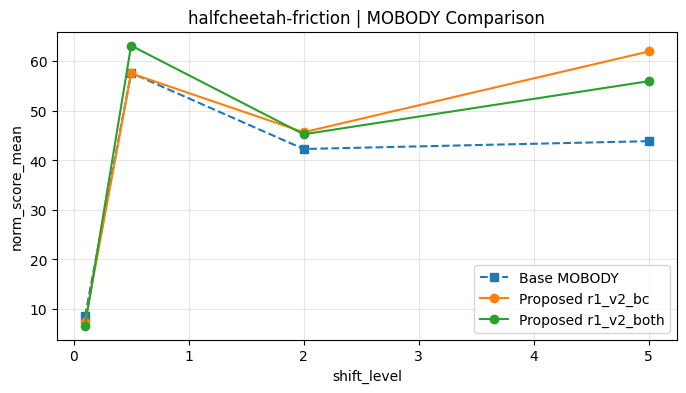

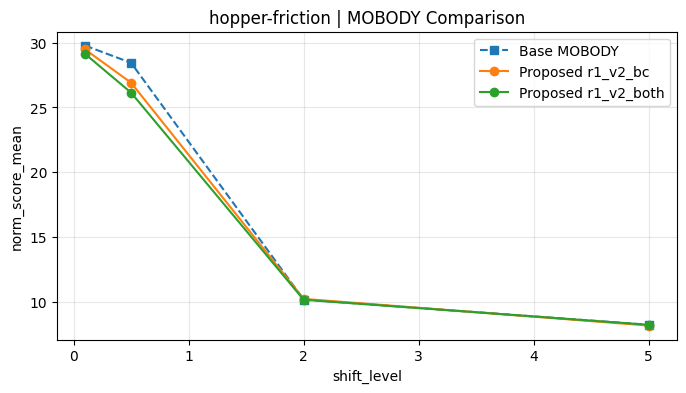

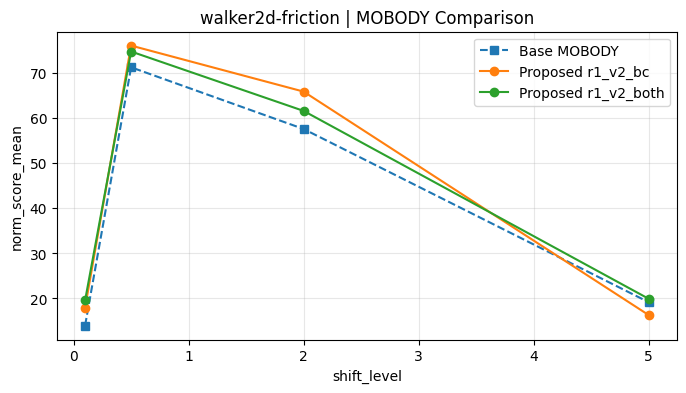

In [94]:
import matplotlib.pyplot as plt

main_metric = "norm_score_mean"

for env in compare["env"].unique():
    tmp = compare[compare["env"] == env].copy()
    
    plt.figure(figsize=(8, 4))
    
    base_tmp = (
        tmp[["shift_level", f"{main_metric}_base"]]
        .drop_duplicates()
        .sort_values("shift_level")
    )
    
    plt.plot(
        base_tmp["shift_level"],
        base_tmp[f"{main_metric}_base"],
        marker="s",
        linestyle="--",
        label="Base MOBODY"
    )
    
    for run_name in tmp["run_name"].unique():
        t = tmp[tmp["run_name"] == run_name].sort_values("shift_level")
        plt.plot(
            t["shift_level"],
            t[f"{main_metric}_prop"],
            marker="o",
            label=f"Proposed {run_name}"
        )
    
    plt.title(f"{env} | MOBODY Comparison")
    plt.xlabel("shift_level")
    plt.ylabel(main_metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [ ]:
# df_base.round(2).to_csv("df_base.csv", index=False)